In [ ]:
# Basic libraries 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pykalman import KalmanFilter
from itertools import combinations
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm
import pickle
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

In [21]:
# Scripts 
from scripts.src.cointegration import *
from scripts.src.kalman import *
from scripts.src.pairs import *
from scripts.src.trading_signal import *
from scripts.src.backtest import *
from scripts.src.plots import *
from scripts.src.utils import *

# Import data <br>
- Create algorithm to compute cointegrated pairs (pairs-det.py)
- Do human check on the pairs that the algorithm chose by plotting pairs and computing simple EDA

In [22]:
# 收集数据来自 Bloomberg 然后将这些对整理到 x 和 y 字典中。 

"""
df1 = tech assets 
df2 = commodities assets 
df = tech + commodities merged together
"""

df1 = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/raw_data/tech.csv")
df2 = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/raw_data/commodites.csv")

df = pd.merge(df1, df2, how='left', on='Date')
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.set_index('Date')
df = df.sort_index()

In [23]:
df.head()

,700 HK Equity,9988 HK Equity,1211 HK Equity,1810 HK Equity,300 HK Equity,981 HK Equity,9999 HK Equity,3690 HK Equity,9618 HK Equity,9888 HK Equity,...,3858 HK Equity,1258 HK Equity,3668 HK Equity,3330 HK Equity,1164 HK Equity,2689 HK Equity,2386 HK Equity,2610 HK Equity,3899 HK Equity,189 HK Equity
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,99.201,167.118,10.025,17.00,51.930,7.4,109.815,69.00,199.037,252.0,...,10.92,1.456,11.021,1.107,0.677,5.111,2.776,26.191,4.633,1.885
2015-01-05,99.817,178.133,10.025,16.80,56.004,7.4,116.405,72.65,206.082,252.0,...,30.34,1.456,10.960,1.090,0.668,5.140,2.829,24.862,4.780,1.925
2015-01-06,105.533,183.450,10.072,19.00,60.885,7.1,115.062,72.10,205.730,250.8,...,30.00,1.456,10.726,1.090,0.659,5.118,2.843,24.862,4.663,1.891
2015-01-07,109.403,193.705,9.219,19.00,60.648,7.2,112.018,69.00,200.798,226.6,...,33.82,1.456,10.655,1.082,0.677,4.894,2.838,23.681,4.648,1.911
2015-01-08,111.953,188.388,9.330,19.26,64.059,7.0,116.137,68.80,202.560,214.0,...,32.50,1.421,10.491,1.140,0.686,4.706,2.819,23.336,4.663,1.898


### Ticker - Company Name
| Ticker (Tech) | Company (Tech)                     | Ticker (Energy/Materials) | Company (Energy/Materials)        |
|---------------|------------------------------------|---------------------------|-----------------------------------|
| 700 HK Equity | TENCENT HOLDINGS LTD              | 857 HK Equity             | PETROCHINA CO LTD-H               |
| 9988 HK Equity| ALIBABA GROUP HOLDING LTD         | 883 HK Equity             | CNOOC LTD-H                       |
| 1211 HK Equity| BYD CO LTD-H                      | 1088 HK Equity            | CHINA SHENHUA ENERGY CO-H         |
| 1810 HK Equity| XIAOMI CORP-CLASS B               | 2899 HK Equity            | ZIJIN MINING GROUP CO LTD-H       |
| 300 HK Equity | MIDEA GROUP CO LTD-H              | 386 HK Equity             | CHINA PETROLEUM & CHEMICAL-H      |
| 981 HK Equity | SEMICONDUCTOR MANUFACTURING-H     | 3993 HK Equity            | CMOC GROUP LTD-H                  |
| 9999 HK Equity| NETEASE INC                       | 2259 HK Equity            | ZIJIN GOLD INTERNATIONAL CO       |
| 3690 HK Equity| MEITUAN-CLASS B                   | 1378 HK Equity            | CHINA HONGQIAO GROUP LTD          |
| 9618 HK Equity| JD.COM INC-CLASS A                | 2600 HK Equity            | ALUMINUM CORP OF CHINA LTD-H      |
| 9888 HK Equity| BAIDU INC-CLASS A                 | 1898 HK Equity            | CHINA COAL ENERGY CO-H            |
| 9961 HK Equity| TRIP.COM GROUP LTD                | 1772 HK Equity            | GANFENG LITHIUM GROUP CO L-H      |
| 6690 HK Equity| HAIER SMART HOME CO LTD-H         | 1787 HK Equity            | SHANDONG GOLD MINING CO LT-H      |
| 1024 HK Equity| KUAISHOU TECHNOLOGY               | 1171 HK Equity            | YANKUANG ENERGY GROUP CO-H        |
| 1347 HK Equity| HUA HONG SEMICONDUCTOR LTD-H      | 358 HK Equity             | JIANGXI COPPER CO LTD-H           |
| 2015 HK Equity| LI AUTO INC-CLASS A               | 1818 HK Equity            | ZHAOJIN MINING INDUSTRY CO-H      |
| 6618 HK Equity| JD HEALTH INTERNATIONAL INC       | 1208 HK Equity            | MMG LTD                           |
| 992 HK Equity | LENOVO GROUP LTD                  | 2099 HK Equity            | CHINA GOLD INTERNATIONAL RES      |
| 9866 HK Equity| NIO INC-CLASS A                   | 2883 HK Equity            | CHINA OILFIELD SERVICES-H         |
| 9868 HK Equity| XPENG INC - CLASS A SHARES        | 2788 HK Equity            | CHUANGXIN INDUSTRIES HOLDING      |
| 1698 HK Equity| TENCENT MUSIC ENT - CLASS A       | 3939 HK Equity            | WANGUO GOLD GROUP LTD             |
| 9660 HK Equity| HORIZON ROBOTICS INC              | 3858 HK Equity            | JIAXIN INTERNATIONAL RESOURC      |
| 20 HK Equity  | SENSE TIME GROUP INC-CLASS B      | 1258 HK Equity            | CHINA NONFERROUS MINING CORP      |
| 9626 HK Equity| BILIBILI INC-CLASS Z              | 3668 HK Equity            | YANCOAL AUSTRALIA LTD             |
| 241 HK Equity | ALIBABA HEALTH INFORMATION TECH   | 3330 HK Equity            | LINGBAO GOLD GROUP CO LTD-H       |
| 9863 HK Equity| ZHEJIANG LEAPMOTOR TECHNOLOGY-H   | 1164 HK Equity            | CGN MINING CO LTD                 |
| 2382 HK Equity| SUNNY OPTICAL TECH                | 2689 HK Equity            | NINE DRAGONS PAPER HOLDINGS       |
| 285 HK Equity | BYD ELECTRONIC INTL CO LTD        | 2386 HK Equity            | SINOPEC ENGINEERING GROUP-H       |
| 780 HK Equity | TONGCHENG TRAVEL HOLDINGS LTD     | 2610 HK Equity            | NANSHAN ALUMINIUM INTERNATIO      |
| 3888 HK Equity| KINGSOFT CORP LTD                 | 3899 HK Equity            | CIMC ENRIC HOLDINGS LTD           |
| 268 HK Equity | KINGDEE INTERNATIONAL SOFTWARE    | 189 HK Equity             | DONGYUE GROUP                     |

*We keep tech and commodities pairs separate from each other to mitigate the issue of spurious regressions from occurring*

In [24]:
# Set the time index for our respective dataframes
df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True)
df1 = df1.set_index('Date')

df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=True)
df2 = df2.set_index('Date')

In [25]:
# Removing equities that don't have enough data

df1 = df1.loc[:'2023-01-31']
last_date = df1.index.max()
df1 = df1.loc[:, df1.loc[last_date].notna()]
df1.head()

,700 HK Equity,1211 HK Equity,981 HK Equity,1347 HK Equity,992 HK Equity,241 HK Equity,2382 HK Equity,285 HK Equity,3888 HK Equity,268 HK Equity
Date,,,,,,,,,,
2015-01-02,99.201,10.025,7.4,8.807,6.069,5.11,12.130,6.923,14.711,2.332
2015-01-05,99.817,10.025,7.4,8.690,5.974,4.97,12.240,7.100,15.243,2.342
2015-01-06,105.533,10.072,7.1,8.923,5.985,5.00,12.111,6.914,15.300,2.303
2015-01-07,109.403,9.219,7.2,8.833,6.187,4.97,11.560,7.286,15.603,2.372
2015-01-08,111.953,9.330,7.0,8.878,6.437,5.00,10.788,7.809,15.338,2.382


In [26]:
df2 = df2.loc[:'2023-01-31']
last_date = df2.index.max()
df2 = df2.loc[:, df2.loc[last_date].notna()]
df2.head()

,857 HK Equity,883 HK Equity,1088 HK Equity,2899 HK Equity,386 HK Equity,3993 HK Equity,1378 HK Equity,2600 HK Equity,1898 HK Equity,1171 HK Equity,...,2099 HK Equity,2883 HK Equity,3939 HK Equity,1258 HK Equity,3330 HK Equity,1164 HK Equity,2689 HK Equity,2386 HK Equity,3899 HK Equity,189 HK Equity
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,4.784,4.775,8.437,1.633,2.768,1.178,2.517,3.189,3.174,1.170,...,11.288,10.835,0.460,1.456,1.107,0.677,5.111,2.776,4.633,1.885
2015-01-05,4.811,4.784,8.546,1.693,2.803,1.238,2.624,3.586,3.251,1.226,...,11.456,10.977,0.466,1.456,1.090,0.668,5.140,2.829,4.780,1.925
2015-01-06,4.696,4.631,8.528,1.707,2.750,1.231,2.605,3.640,3.200,1.224,...,11.589,10.427,0.474,1.456,1.090,0.659,5.118,2.843,4.663,1.891
2015-01-07,4.718,4.622,8.564,1.744,2.750,1.254,2.571,3.739,3.219,1.224,...,11.840,10.490,0.480,1.456,1.082,0.677,4.894,2.838,4.648,1.911
2015-01-08,4.833,4.703,8.473,1.811,2.763,1.248,2.576,3.694,3.200,1.234,...,11.522,10.584,0.482,1.421,1.140,0.686,4.706,2.819,4.663,1.898


In [27]:
# Transforming raw prices into log prices
df1 = np.log(df1)
df2 = np.log(df2)

Therefore, with tech, we can have 45 potential pairs and with commodities we can have 253 (*210*) potential pairs, given:
$$
\text{Pairs} = \frac{(n\times(n-1))}{2}
$$

### Calculate Returns and run basic EDA (identify outliers and form correlation matrix)

$$
r_t = ln(\frac{P_{t}}{P_{t-1}})
$$

In [28]:
# For tech
tech_returns = (df1 - df1.shift(1)).dropna()
print(tech_returns)

# For commodities
comm_returns = (df2 - df2.shift(1)).dropna()
print(comm_returns)

            700 HK Equity  1211 HK Equity  981 HK Equity  1347 HK Equity  \
Date                                                                       
2015-01-05       0.006190        0.000000       0.000000       -0.013374   
2015-01-06       0.055685        0.004677      -0.041385        0.026459   
2015-01-07       0.036015       -0.088493       0.013986       -0.010138   
2015-01-08       0.023041        0.011968      -0.028171        0.005082   
2015-01-09      -0.000786        0.011721       0.014185       -0.022440   
...                   ...             ...            ...             ...   
2023-01-20       0.023238       -0.000874       0.016998        0.004836   
2023-01-26       0.037571        0.058331       0.033152        0.065236   
2023-01-27       0.019956        0.025502      -0.004357       -0.006024   
2023-01-30      -0.069336       -0.027167      -0.051523       -0.052822   
2023-01-31      -0.012998        0.022279      -0.009238       -0.037365   

           

### Splitting data
Before proceeding, we should split our data into a test and training set to ensure that our strategy has some rigour on OOS performance

In [29]:
split_date = "2021-01-01"

df1_is = df1.loc[df1.index < split_date].copy()
df1_oos = df1.loc[df1.index >= split_date].copy()

df2_is = df2.loc[df2.index < split_date].copy()
df2_oos = df2.loc[df2.index >= split_date].copy()

tech_returns_is = tech_returns.loc[tech_returns.index < split_date].copy()
tech_returns_oos = tech_returns.loc[tech_returns.index >= split_date].copy()

comm_returns_is = comm_returns.loc[comm_returns.index < split_date].copy()
comm_returns_oos = comm_returns.loc[comm_returns.index >= split_date].copy()

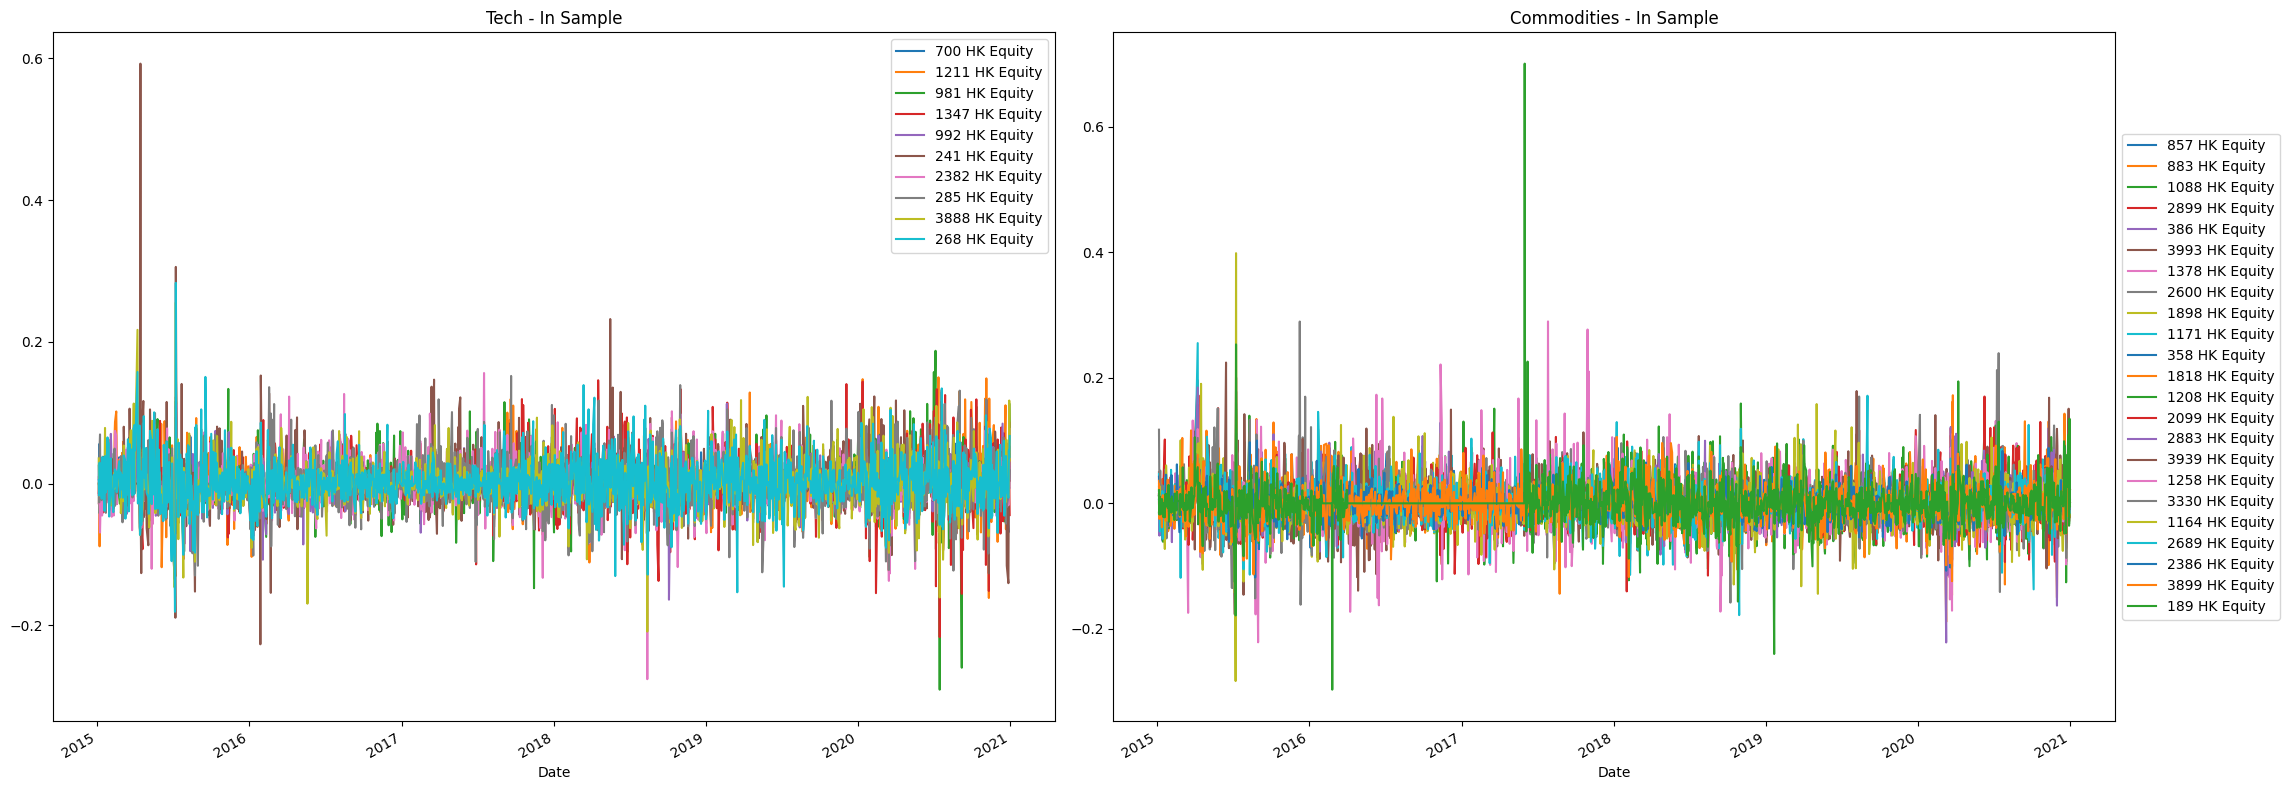

In [30]:
# Checking for outliers visually

fig, axes = plt.subplots(1, 2, figsize=(23, 8))

tech_returns_is.plot(ax=axes[0])
axes[0].set_title("Tech - In Sample")

comm_returns_is.plot(ax=axes[1])
axes[1].set_title("Commodities - In Sample")
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

In [31]:
# Checking individual plots
output_folder = "/Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/plots"
os.makedirs(output_folder, exist_ok=True)

for asset in comm_returns_is.columns:
    
    plt.figure(figsize=(10, 4))
    
    comm_returns_is[asset].plot()
    plt.title(asset)
    plt.xlabel("Date")
    plt.ylabel("Returns")
    
    filename = asset.replace(" ", "_") + ".png"
    filepath = os.path.join(output_folder, filename)
    
    plt.savefig(filepath)
    plt.close()

for asset in tech_returns_is.columns:
    
    plt.figure(figsize=(10, 4))
    
    tech_returns_is[asset].plot()
    plt.title(asset)
    plt.xlabel("Date")
    plt.ylabel("Returns")
    
    filename = asset.replace(" ", "_") + ".png"
    filepath = os.path.join(output_folder, filename)
    
    plt.savefig(filepath)
    plt.close()

"""
Looking at the plots individually, we find that 189 and 1378 HK Equity have
0 change for an extended period of time, hence we remove it.
"""

comm_returns = comm_returns.drop(["189 HK Equity", "1378 HK Equity"], axis=1)
comm_returns.columns

Index(['857 HK Equity', '883 HK Equity', '1088 HK Equity', '2899 HK Equity',
       '386 HK Equity', '3993 HK Equity', '2600 HK Equity', '1898 HK Equity',
       '1171 HK Equity', '358 HK Equity', '1818 HK Equity', '1208 HK Equity',
       '2099 HK Equity', '2883 HK Equity', '3939 HK Equity', '1258 HK Equity',
       '3330 HK Equity', '1164 HK Equity', '2689 HK Equity', '2386 HK Equity',
       '3899 HK Equity'],
      dtype='str')

![image](/Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/plots/189_HK_Equity.png)![image](/Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/plots/1378_HK_Equity.png)


In [32]:
# Check for outliers with the > 5 standard deviations rule
tech_flags = flag_extreme_zscore(tech_returns_is)
tech_outliers = tech_returns_is[tech_flags].stack().dropna()
print("Tech outlier assets before winsorization:",
      list(tech_outliers.index.get_level_values(1).unique()))

comm_flags = flag_extreme_zscore(comm_returns_is)
comm_outliers = comm_returns_is[comm_flags].stack().dropna()
print("Comm outlier assets before winsorization:",
      list(comm_outliers.index.get_level_values(1).unique()))

Tech outlier assets before winsorization: ['3888 HK Equity', '241 HK Equity', '268 HK Equity', '2382 HK Equity', '992 HK Equity', '981 HK Equity', '1347 HK Equity', '1211 HK Equity']
Comm outlier assets before winsorization: ['1378 HK Equity', '3993 HK Equity', '1898 HK Equity', '1171 HK Equity', '358 HK Equity', '2883 HK Equity', '2099 HK Equity', '1164 HK Equity', '2899 HK Equity', '3939 HK Equity', '189 HK Equity', '1818 HK Equity', '3330 HK Equity', '2386 HK Equity', '1258 HK Equity', '883 HK Equity', '2689 HK Equity', '1088 HK Equity', '3899 HK Equity', '2600 HK Equity', '1208 HK Equity', '857 HK Equity', '386 HK Equity']


In [33]:
# Winsorize returns to mitigate data errors and extreme spikes
tech_returns_win = winsorize(tech_returns_is)
comm_returns_win = winsorize(comm_returns_is)

In [34]:
# Check whether there are any outliers remaining after winsorization
tech_flags_win = flag_extreme_zscore(tech_returns_win)
tech_outliers_win = tech_returns_win[tech_flags_win].stack().dropna()
print("Tech remaining outlier assets:",
      list(tech_outliers_win.index.get_level_values(1).unique()))

comm_flags_win = flag_extreme_zscore(comm_returns_win)
comm_outliers_win = comm_returns_win[comm_flags_win].stack().dropna()
print("Comm remaining outlier assets:",
      list(comm_outliers_win.index.get_level_values(1).unique()))

Tech remaining outlier assets: []
Comm remaining outlier assets: []


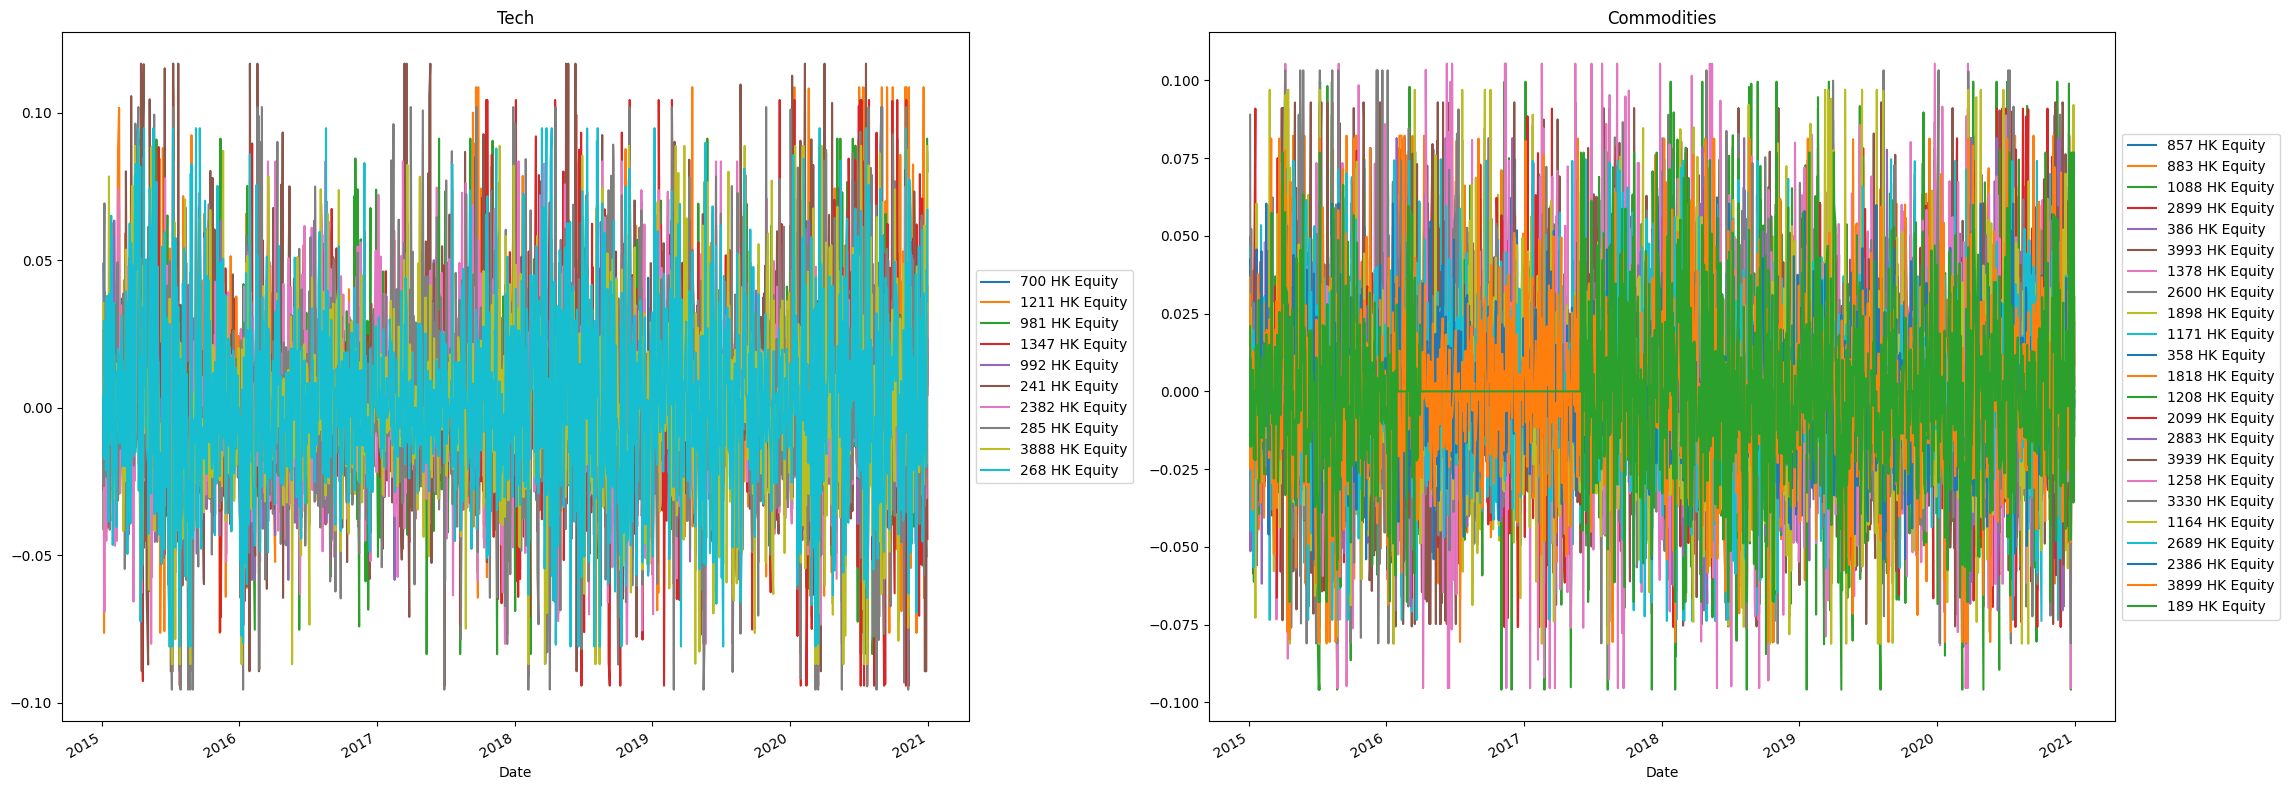

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(23, 8))

tech_returns_win.plot(ax=axes[0], legend=True)
axes[0].set_title("Tech")
axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))

comm_returns_win.plot(ax=axes[1], legend=True)
axes[1].set_title("Commodities")
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

### Correlation Matrix 

Simple analysis and see whether some equities are highly correlated or not to identify any key patterns between them

In [36]:
# Name remapping
tech_name_map = {
    "700 HK Equity": "700 (Tencent)",
    "9988 HK Equity": "9988 (Alibaba)",
    "1211 HK Equity": "1211 (BYD)",
    "1810 HK Equity": "1810 (Xiaomi)",
    "300 HK Equity": "300 (Midea)",
    "981 HK Equity": "981 (SMIC)",
    "9999 HK Equity": "9999 (NetEase)",
    "3690 HK Equity": "3690 (Meituan)",
    "9618 HK Equity": "9618 (JD.com)",
    "9888 HK Equity": "9888 (Baidu)",
    "9961 HK Equity": "9961 (Trip.com)",
    "6690 HK Equity": "6690 (Haier)",
    "1024 HK Equity": "1024 (Kuaishou)",
    "1347 HK Equity": "1347 (Hua Hong Semi)",
    "2015 HK Equity": "2015 (Li Auto)",
    "6618 HK Equity": "6618 (JD Health)",
    "992 HK Equity": "992 (Lenovo)",
    "9866 HK Equity": "9866 (NIO)",
    "9868 HK Equity": "9868 (XPeng)",
    "1698 HK Equity": "1698 (Tencent Music)",
    "9660 HK Equity": "9660 (Horizon Robotics)",
    "20 HK Equity": "20 (SenseTime)",
    "9626 HK Equity": "9626 (Bilibili)",
    "241 HK Equity": "241 (Alibaba Health)",
    "9863 HK Equity": "9863 (Leapmotor)",
    "2382 HK Equity": "2382 (Sunny Optical)",
    "285 HK Equity": "285 (BYD Electronic)",
    "780 HK Equity": "780 (Tongcheng Travel)",
    "3888 HK Equity": "3888 (Kingsoft)",
    "268 HK Equity": "268 (Kingdee)"
}
comm_name_map = {
    "857 HK Equity": "857 (PetroChina)",
    "883 HK Equity": "883 (CNOOC)",
    "1088 HK Equity": "1088 (China Shenhua)",
    "2899 HK Equity": "2899 (Zijin Mining)",
    "386 HK Equity": "386 (Sinopec)",
    "3993 HK Equity": "3993 (CMOC)",
    "2259 HK Equity": "2259 (Zijin Gold Int.)",
    "2600 HK Equity": "2600 (Aluminum Corp)",
    "1898 HK Equity": "1898 (China Coal)",
    "1772 HK Equity": "1772 (Ganfeng Lithium)",
    "1787 HK Equity": "1787 (Shandong Gold)",
    "1171 HK Equity": "1171 (Yankuang Energy)",
    "358 HK Equity": "358 (Jiangxi Copper)",
    "1818 HK Equity": "1818 (Zhaojin Mining)",
    "1208 HK Equity": "1208 (MMG)",
    "2099 HK Equity": "2099 (China Gold Int.)",
    "2883 HK Equity": "2883 (China Oilfield)",
    "2788 HK Equity": "2788 (Chuangxin Ind.)",
    "3939 HK Equity": "3939 (Wanguo Gold)",
    "3858 HK Equity": "3858 (Jiaxin Res.)",
    "1258 HK Equity": "1258 (China Nonferrous)",
    "3668 HK Equity": "3668 (Yancoal)",
    "3330 HK Equity": "3330 (Lingbao Gold)",
    "1164 HK Equity": "1164 (CGN Mining)",
    "2689 HK Equity": "2689 (Nine Dragons)",
    "2386 HK Equity": "2386 (Sinopec Eng.)",
    "2610 HK Equity": "2610 (Nanshan Aluminium)",
    "3899 HK Equity": "3899 (CIMC Enric)",
}

tech_returns_win = tech_returns_win.rename(columns=lambda x: tech_name_map.get(x, x))
comm_returns_win = comm_returns_win.rename(columns=lambda x: comm_name_map.get(x, x))

In [37]:
# Forming correlation matrices
tech_corr_matrix = tech_returns_win.corr()
comm_corr_matrix = comm_returns_win.corr()

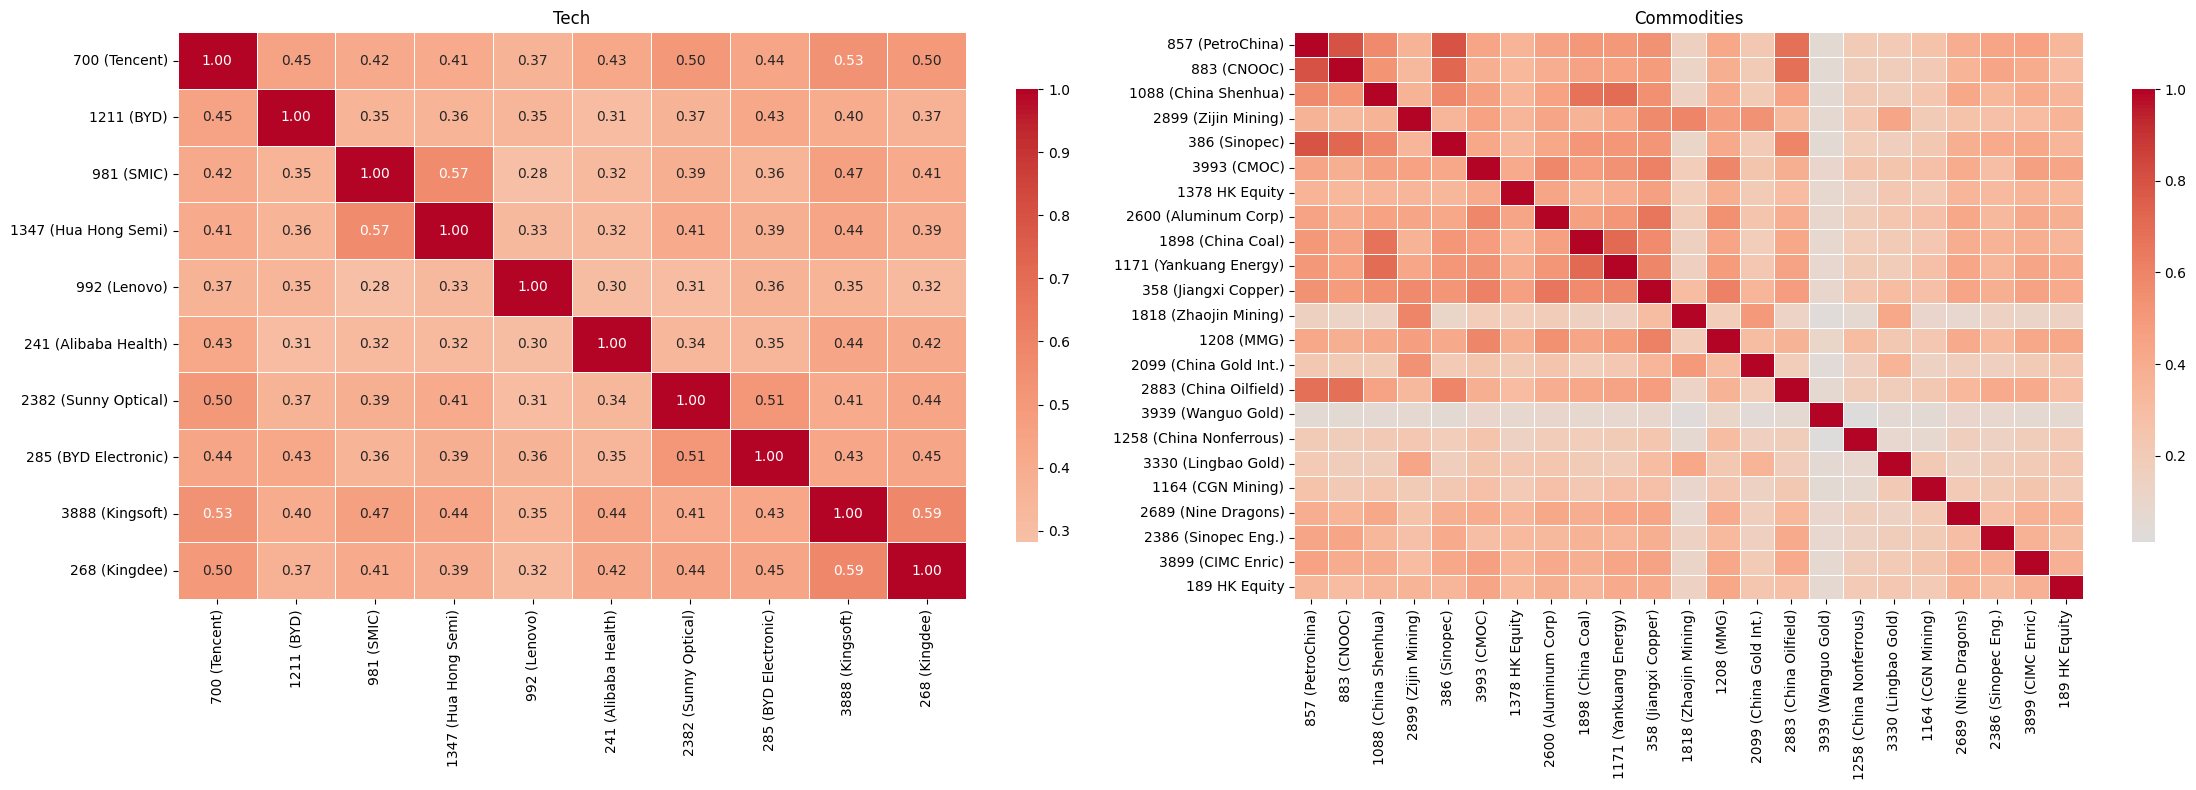

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(23, 8))

# Tech heatmap
sns.heatmap(
    tech_corr_matrix,
    ax=axes[0],
    cmap="coolwarm",
    annot=True,        
    fmt=".2f", 
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
axes[0].set_title("Tech")

# Commodities heatmap
sns.heatmap(
    comm_corr_matrix,
    ax=axes[1],
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
axes[1].set_title("Commodities")

plt.tight_layout()
plt.show()

In [39]:
# Save data 

df1_is.to_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/df1_is", index=False)
df1_oos.to_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/df1_oos", index=False)

df2_is.to_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/df2_is", index=False)
df2_oos.to_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/df2_oos", index=False)